In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
from torch import nn, Tensor

# Dataset SetUp

In [2]:
data = np.load("DrellYan.npz")
data_H = np.load("Higgs.npz")

taus = data["x_taus"]        # shape (N, 2, 18)
tauprod = data["x_tauprod"]  # shape (N, 10, 10)
met = data["x_met"]          # shape (N, 1, 8)
jets = data["x_jets"]        # shape (N, 3, 4)

target = data["target"]      # (N, 2, 1) gen-level log(pt) of taus
m_reco = data["inv_mass_reco"]  # (N,)
m_target = data["inv_mass_tar"] # (N,)


taus_H   = data_H["x_taus"]          # (N, 2, 18)
tauprod_H = data_H["x_tauprod"]      # (N, 10, 10)
met_H    = data_H["x_met"]           # (N, 1, 8)
jets_H   = data_H["x_jets"]          # (N, 3, 4)

target_H = data_H["target"]          # (N, 2, 1)
m_reco_H  = data_H["inv_mass_reco"]   # (N,)
m_target_H = data_H["inv_mass_tar"]   # (N,)

In [3]:
df = pd.DataFrame({
    "tau1_logpt": taus[:,0,0],
    "tau1_eta":   taus[:,0,1],
    "tau1_phi":   taus[:,0,2],
    "tau1_mass":  taus[:,0,3],
    "tau1_dxy":   taus[:,0,4],
    "tau1_dz":    taus[:,0,5],
    "tau1_ptCorrPNet": taus[:,0,6],
    "tau1_rawPNetVSjet": taus[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus[:,0,8],
    "tau1_charge": taus[:,0,9],
    
    # decay mode indicator columns 
    "tau1_dM_0":  taus[:,0,10],
    "tau1_dM_1":  taus[:,0,11],
    "tau1_dM_2":  taus[:,0,12],
    "tau1_dM_10": taus[:,0,13],
    "tau1_dM_11": taus[:,0,14],
    
    "tau1_leadTkDeltaEta": taus[:,0,15],
    "tau1_leadTkDeltaPhi": taus[:,0,16],
    "tau1_leadTkPtOverTauPt": taus[:,0,17],

    "tau2_logpt": taus[:,1,0],
    "tau2_eta":   taus[:,1,1],
    "tau2_phi":   taus[:,1,2],
    "tau2_mass":  taus[:,1,3],
    "tau2_dxy":   taus[:,1,4],
    "tau2_dz":    taus[:,1,5],
    "tau2_ptCorrPNet": taus[:,1,6],
    "tau2_rawPNetVSjet": taus[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus[:,1,8],
    "tau2_charge": taus[:,1,9],

    "tau2_dM_0":  taus[:,1,10],
    "tau2_dM_1":  taus[:,1,11],
    "tau2_dM_2":  taus[:,1,12],
    "tau2_dM_10": taus[:,1,13],
    "tau2_dM_11": taus[:,1,14],

    "tau2_leadTkDeltaEta": taus[:,1,15],
    "tau2_leadTkDeltaPhi": taus[:,1,16],
    "tau2_leadTkPtOverTauPt": taus[:,1,17],

    "gen_tau1_logpt": target[:,0,0],
    "gen_tau2_logpt": target[:,1,0],

    "inv_mass_reco": m_reco,
    "inv_mass_tar":  m_target,
})


df_H = pd.DataFrame({
    "tau1_logpt": taus_H[:,0,0],
    "tau1_eta":   taus_H[:,0,1],
    "tau1_phi":   taus_H[:,0,2],
    "tau1_mass":  taus_H[:,0,3],
    "tau1_dxy":   taus_H[:,0,4],
    "tau1_dz":    taus_H[:,0,5],
    "tau1_ptCorrPNet": taus_H[:,0,6],
    "tau1_rawPNetVSjet": taus_H[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus_H[:,0,8],
    "tau1_charge": taus_H[:,0,9],
    
    # decay mode indicator columns (same as DY)
    "tau1_dM_0":  taus_H[:,0,10],
    "tau1_dM_1":  taus_H[:,0,11],
    "tau1_dM_2":  taus_H[:,0,12],
    "tau1_dM_10": taus_H[:,0,13],
    "tau1_dM_11": taus_H[:,0,14],
    
    "tau1_leadTkDeltaEta": taus_H[:,0,15],
    "tau1_leadTkDeltaPhi": taus_H[:,0,16],
    "tau1_leadTkPtOverTauPt": taus_H[:,0,17],

    "tau2_logpt": taus_H[:,1,0],
    "tau2_eta":   taus_H[:,1,1],
    "tau2_phi":   taus_H[:,1,2],
    "tau2_mass":  taus_H[:,1,3],
    "tau2_dxy":   taus_H[:,1,4],
    "tau2_dz":    taus_H[:,1,5],
    "tau2_ptCorrPNet": taus_H[:,1,6],
    "tau2_rawPNetVSjet": taus_H[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus_H[:,1,8],
    "tau2_charge": taus_H[:,1,9],

    "tau2_dM_0":  taus_H[:,1,10],
    "tau2_dM_1":  taus_H[:,1,11],
    "tau2_dM_2":  taus_H[:,1,12],
    "tau2_dM_10": taus_H[:,1,13],
    "tau2_dM_11": taus_H[:,1,14],

    "tau2_leadTkDeltaEta": taus_H[:,1,15],
    "tau2_leadTkDeltaPhi": taus_H[:,1,16],
    "tau2_leadTkPtOverTauPt": taus_H[:,1,17],

    "gen_tau1_logpt": target_H[:,0,0],
    "gen_tau2_logpt": target_H[:,1,0],

    "inv_mass_reco": m_reco_H,
    "inv_mass_tar":  m_target_H,
})


In [4]:
df["tau1_pt_reco"] = np.exp(df["tau1_logpt"])
df["tau2_pt_reco"] = np.exp(df["tau2_logpt"])

df["tau1_pt_gen"] = df["gen_tau1_logpt"]
df["tau2_pt_gen"] = df["gen_tau2_logpt"]


df_H["tau1_pt_reco"] = np.exp(df_H["tau1_logpt"])
df_H["tau2_pt_reco"] = np.exp(df_H["tau2_logpt"])

df_H["tau1_pt_gen"] = df_H["gen_tau1_logpt"]
df_H["tau2_pt_gen"] = df_H["gen_tau2_logpt"]

df["tau1_ptreco_over_ptgen"] = df["tau1_pt_reco"]/df["tau1_pt_gen"]
df["tau2_ptreco_over_ptgen"] = df["tau2_pt_reco"]/df["tau2_pt_gen"]

df_H["tau1_ptreco_over_ptgen"] = df_H["tau1_pt_reco"]/df_H["tau1_pt_gen"]
df_H["tau2_ptreco_over_ptgen"] = df_H["tau2_pt_reco"]/df_H["tau2_pt_gen"]

In [5]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df["tau1_logpt"] > log_pt_min) & (df["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel = df[mask_pt].copy()

mask_pt_H = (df_H["tau1_logpt"] > log_pt_min) & (df_H["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_H))
print("Eventi che passano pT>30 GeV (in log):", mask_pt_H.sum())

df_H_sel = df_H[mask_pt_H].copy()

Eventi totali: 335263
Eventi che passano pT>30 GeV (in log): 69198
Eventi totali: 355225
Eventi che passano pT>30 GeV (in log): 158632


In [6]:
df_sel["tau1_abs_eta"] = df_sel["tau1_eta"].abs()
df_sel["tau2_abs_eta"] = df_sel["tau2_eta"].abs()

df_sel["tau1_is_barrel"] = df_sel["tau1_abs_eta"] < 1.4
df_sel["tau1_is_endcap"] = ~df_sel["tau1_is_barrel"]

df_sel["tau2_is_barrel"] = df_sel["tau2_abs_eta"] < 1.4
df_sel["tau2_is_endcap"] = ~df_sel["tau2_is_barrel"]


df_H_sel["tau1_abs_eta"] = df_H_sel["tau1_eta"].abs()
df_H_sel["tau2_abs_eta"] = df_H_sel["tau2_eta"].abs()

df_H_sel["tau1_is_barrel"] = df_H_sel["tau1_abs_eta"] < 1.4
df_H_sel["tau1_is_endcap"] = ~df_H_sel["tau1_is_barrel"]

df_H_sel["tau2_is_barrel"] = df_H_sel["tau2_abs_eta"] < 1.4
df_H_sel["tau2_is_endcap"] = ~df_H_sel["tau2_is_barrel"]

In [7]:
summary = pd.DataFrame({
    "Process": ["Drell–Yan", "Higgs"],
    "Total events": [len(df), len(df_H)],
    "After pT>30 GeV cut": [mask_pt.sum(), mask_pt_H.sum()]
})

summary["Retention (%)"] = 100 * summary["After pT>30 GeV cut"] / summary["Total events"]
summary


,Process,Total events,After pT>30 GeV cut,Retention (%)
0,Drell–Yan,335263,69198,20.639916
1,Higgs,355225,158632,44.656767


In [8]:
# Plot m_reco, m_tar e risoluzione :

# DY (dopo taglio pT)
m_reco_DY    = df_sel["inv_mass_reco"].values
m_target_DY  = df_sel["inv_mass_tar"].values

# Higgs (dopo taglio pT)
m_reco_H     = df_H_sel["inv_mass_reco"].values
m_target_H   = df_H_sel["inv_mass_tar"].values

# Risoluzioni relative
res_DY = (m_reco_DY - m_target_DY) / m_target_DY
res_H  = (m_reco_H  - m_target_H) / m_target_H

In [9]:
df_sel["tau1_response"] = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau1_resolution"] = (df_sel["tau1_pt_reco"] - df_sel["tau1_pt_gen"]) / df_sel["tau1_pt_gen"]

df_sel["tau2_response"] = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]
df_sel["tau2_resolution"] = (df_sel["tau2_pt_reco"] - df_sel["tau2_pt_gen"]) / df_sel["tau2_pt_gen"]


df_H_sel["tau1_response"] = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau1_resolution"] = (df_H_sel["tau1_pt_reco"] - df_H_sel["tau1_pt_gen"]) / df_H_sel["tau1_pt_gen"]

df_H_sel["tau2_response"] = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]
df_H_sel["tau2_resolution"] = (df_H_sel["tau2_pt_reco"] - df_H_sel["tau2_pt_gen"]) / df_H_sel["tau2_pt_gen"]

# pT corretta con PNet
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# response corretta
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]


# pT corretta con PNet
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# response corretta
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]


In [10]:
dm_map = {
    "dM_0": 0, "dM_1": 1, "dM_2": 2,
    "dM_10": 10, "dM_11": 11
}

dm_values = [0, 1, 2, 10, 11]

dm_labels = {
    0: "DM 0 (1-prong, 0 π0)",
    1: "DM 1 (1-prong, 1 π0)",
    2: "DM 2 (1-prong, 2 π0)",
    10: "DM 10 (3-prong, 0 π0)",
    11: "DM 11 (3-prong, 1 π0)",
}


# DY
df_sel["tau1_dm"] = (
      df_sel["tau1_dM_0"]  * 0
    + df_sel["tau1_dM_1"]  * 1
    + df_sel["tau1_dM_2"]  * 2
    + df_sel["tau1_dM_10"] * 10
    + df_sel["tau1_dM_11"] * 11
)

df_sel["tau2_dm"] = (
      df_sel["tau2_dM_0"]  * 0
    + df_sel["tau2_dM_1"]  * 1
    + df_sel["tau2_dM_2"]  * 2
    + df_sel["tau2_dM_10"] * 10
    + df_sel["tau2_dM_11"] * 11
)

# Higgs
df_H_sel["tau1_dm"] = (
      df_H_sel["tau1_dM_0"]  * 0
    + df_H_sel["tau1_dM_1"]  * 1
    + df_H_sel["tau1_dM_2"]  * 2
    + df_H_sel["tau1_dM_10"] * 10
    + df_H_sel["tau1_dM_11"] * 11
)

df_H_sel["tau2_dm"] = (
      df_H_sel["tau2_dM_0"]  * 0
    + df_H_sel["tau2_dM_1"]  * 1
    + df_H_sel["tau2_dM_2"]  * 2
    + df_H_sel["tau2_dM_10"] * 10
    + df_H_sel["tau2_dM_11"] * 11
)

In [11]:
# definizioni utili
# ----- DY -----
df_sel["tau1_response"]   = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response"]   = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution"] = df_sel["tau1_response"] - 1.0
df_sel["tau2_resolution"] = df_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution_corrPNet"] = df_sel["tau1_response_corrPNet"] - 1.0
df_sel["tau2_resolution_corrPNet"] = df_sel["tau2_response_corrPNet"] - 1.0


# ----- HIGGS -----
df_H_sel["tau1_response"]   = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response"]   = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution"] = df_H_sel["tau1_response"] - 1.0
df_H_sel["tau2_resolution"] = df_H_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution_corrPNet"] = df_H_sel["tau1_response_corrPNet"] - 1.0
df_H_sel["tau2_resolution_corrPNet"] = df_H_sel["tau2_response_corrPNet"] - 1.0


# $\tau$ ID

In [12]:
# ================================
# EVENT-LEVEL VALID — Drell–Yan
# (tengo solo eventi con tau1 e tau2 validi)
# ================================

df_sel_valid = df_sel[
    (df_sel["tau1_rawPNetVSjet"] != -1) &
    (df_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("DY valid events =", len(df_sel_valid))


# ================================
# EVENT-LEVEL VALID — Higgs
# ================================

df_H_sel_valid = df_H_sel[
    (df_H_sel["tau1_rawPNetVSjet"] != -1) &
    (df_H_sel["tau2_rawPNetVSjet"] != -1)
].copy()

print("Higgs valid events =", len(df_H_sel_valid))


DY valid events = 68774
Higgs valid events = 157892


In [13]:
df_sel_tau1_valid = df_sel_valid.copy()
df_sel_tau2_valid = df_sel_valid.copy()

df_H_sel_tau1_valid = df_H_sel_valid.copy()
df_H_sel_tau2_valid = df_H_sel_valid.copy()

print("\nCheck lengths:")
print("DY:", len(df_sel_tau1_valid), len(df_sel_tau2_valid))
print("H :", len(df_H_sel_tau1_valid), len(df_H_sel_tau2_valid))



Check lengths:
DY: 68774 68774
H : 157892 157892


In [14]:
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90


# ================================================
# TAU1 — HIGGS (event-level sample)
# ================================================
vals_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"].values

# soglie possibili
thresholds_tau1 = np.sort(np.unique(vals_tau1))

# efficienza: P(rawPNet > thr)
eff_tau1 = np.array([
    np.mean(vals_tau1 > thr) for thr in thresholds_tau1
])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(
    thresholds_tau1, eff_tau1, target_eff
)

print(f"[Higgs] Tau1: soglia = {thr_tau1:.6f}, efficienza ≈ {eff_at_thr_tau1:.4f}")


# ================================================
# TAU2 — HIGGS (event-level sample)
# ================================================
vals_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"].values

thresholds_tau2 = np.sort(np.unique(vals_tau2))

eff_tau2 = np.array([
    np.mean(vals_tau2 > thr) for thr in thresholds_tau2
])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(
    thresholds_tau2, eff_tau2, target_eff
)

print(f"[Higgs] Tau2: soglia = {thr_tau2:.6f}, efficienza ≈ {eff_at_thr_tau2:.4f}")


[Higgs] Tau1: soglia = 0.642090, efficienza ≈ 0.9000
[Higgs] Tau2: soglia = 0.495850, efficienza ≈ 0.9000


In [15]:
# ============================
# HIGGS: applico le soglie (EVENT-LEVEL)
# ============================

mask_H_tau1 = df_H_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_H_tau2 = df_H_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_H_evt  = mask_H_tau1 & mask_H_tau2

df_H_sel_tauID = df_H_sel_valid[mask_H_evt].copy()

# efficienza event-level (questa è quella “giusta”)
eff_H_evt = mask_H_evt.mean() if len(df_H_sel_valid) > 0 else float("nan")

print("[Higgs] efficienze con soglie (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_H_evt:.4f}")

# diagnostica: efficienze “oggetto” sullo stesso sample di eventi validi
eff_H_tau1_obj = mask_H_tau1.mean() if len(df_H_sel_valid) > 0 else float("nan")
eff_H_tau2_obj = mask_H_tau2.mean() if len(df_H_sel_valid) > 0 else float("nan")
print("[Higgs] (oggetto, stesso sample):")
print(f"  tau1: {eff_H_tau1_obj:.4f}")
print(f"  tau2: {eff_H_tau2_obj:.4f}")


# ============================
# DY: applico le STESSE soglie (EVENT-LEVEL)
# ============================

mask_DY_tau1 = df_sel_valid["tau1_rawPNetVSjet"] > thr_tau1
mask_DY_tau2 = df_sel_valid["tau2_rawPNetVSjet"] > thr_tau2
mask_DY_evt  = mask_DY_tau1 & mask_DY_tau2

df_sel_tauID = df_sel_valid[mask_DY_evt].copy()

eff_DY_evt = mask_DY_evt.mean() if len(df_sel_valid) > 0 else float("nan")

print("\n[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):")
print(f"  eventi (tau1 & tau2): {eff_DY_evt:.4f}")

# diagnostica: oggetto
eff_DY_tau1_obj = mask_DY_tau1.mean() if len(df_sel_valid) > 0 else float("nan")
eff_DY_tau2_obj = mask_DY_tau2.mean() if len(df_sel_valid) > 0 else float("nan")
print("[DY] (oggetto, stesso sample):")
print(f"  tau1: {eff_DY_tau1_obj:.4f}")
print(f"  tau2: {eff_DY_tau2_obj:.4f}")



[Higgs] efficienze con soglie (event-level AND):
  eventi (tau1 & tau2): 0.8109
[Higgs] (oggetto, stesso sample):
  tau1: 0.9000
  tau2: 0.9000

[DY] efficienze risultanti con soglie fissate da Higgs (event-level AND):
  eventi (tau1 & tau2): 0.7477
[DY] (oggetto, stesso sample):
  tau1: 0.8526
  tau2: 0.8725


In [16]:
df_tauid_thresholds = pd.DataFrame({
    "Tau": ["Tau1", "Tau2"],
    "Threshold (rawPNet)": [thr_tau1, thr_tau2],
    "Target object efficiency (%)": [90.0, 90.0],
    "Higgs object efficiency (%)": [
        eff_H_tau1_obj * 100,
        eff_H_tau2_obj * 100
    ],
    "DY object efficiency (%)": [
        eff_DY_tau1_obj * 100,
        eff_DY_tau2_obj * 100
    ]
})

df_tauid_thresholds = df_tauid_thresholds.set_index("Tau")
df_tauid_thresholds


,Threshold (rawPNet),Target object efficiency (%),Higgs object efficiency (%),DY object efficiency (%)
Tau,,,,
Tau1,0.64209,90.0,90.003293,85.261872
Tau2,0.49585,90.0,90.004560,87.249542


In [17]:
df_DY_event = df_sel_tauID.copy()
df_H_event = df_H_sel_tauID.copy()

In [18]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,0.914873,-0.085127,45.458812,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,0.850390,-0.149610,41.289354,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,0.979220,-0.020780,49.131415,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,0.618578,-0.381422,52.639059,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,0.735075,-0.264925,32.415494,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,0.822673,-0.177327,38.143286,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,0.657699,-0.342301,38.372454,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,0.730076,-0.269924,37.095369,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,0.696674,-0.303326,35.228097,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997


In [19]:
df_H_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_response,tau2_resolution,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet
0,3.750918,0.149750,-2.504883,0.919922,0.001779,0.000654,1.097656,0.985840,0.997559,1.0,...,0.845754,-0.154246,46.716416,44.649644,0.836088,0.989466,1.0,1.0,-0.163912,-0.010534
1,3.908546,-0.357422,-2.585938,0.139526,0.006088,0.012403,0.971680,0.966797,0.997559,1.0,...,0.897412,-0.102588,48.415350,42.992980,0.780893,0.924580,0.0,0.0,-0.219107,-0.075420
6,3.735467,0.549683,1.355957,0.788574,0.002239,0.000944,1.020508,0.999023,0.999512,-1.0,...,0.818558,-0.181442,42.767043,31.457024,0.715766,0.830548,1.0,0.0,-0.284234,-0.169452
10,3.729789,0.430664,-0.860352,0.687012,0.011436,-0.025360,1.043945,0.988281,0.999512,1.0,...,0.531978,-0.468022,43.501531,38.147589,0.805584,0.544966,1.0,1.0,-0.194416,-0.455034
14,4.210932,1.539795,0.115631,8.835938,-0.506348,1.439453,0.895996,0.809082,-1.000000,1.0,...,0.586712,-0.413288,60.407485,38.603266,0.891623,0.630257,1.0,0.0,-0.108377,-0.369743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355215,4.048012,-0.148254,-0.296021,0.499023,0.006256,-0.002593,1.053711,0.997070,0.991211,1.0,...,0.647763,-0.352237,60.360228,43.611693,0.981467,0.758464,1.0,1.0,-0.018533,-0.241536
355216,3.832828,-1.078857,-1.057373,1.222656,-0.000417,-0.002056,1.019531,0.999023,0.994629,-1.0,...,0.816822,-0.183178,47.095196,35.609318,0.765776,0.802464,10.0,1.0,-0.234224,-0.197536
355217,4.351929,0.073349,-0.372009,13.562500,-0.004543,3.602661,0.901855,0.769531,-1.000000,-1.0,...,0.563180,-0.436820,70.009306,31.586895,0.952508,0.576930,2.0,1.0,-0.047492,-0.423070
355219,3.875998,0.232666,1.962646,5.148438,0.012688,0.028769,0.967773,0.999023,-1.000000,-1.0,...,0.722039,-0.277961,46.676508,41.002581,0.608163,0.805948,2.0,1.0,-0.391837,-0.194052


# Model

In [20]:
import time
import torch

from torch import nn, Tensor

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt

from matplotlib import cm


# To avoide meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [21]:
# ===== TAU 1 =====

# dataframe event-level DY post TauID
# df_DY_tau1 = df_DY_event

# x = target (gen pT del tau1)  [è già pT in GeV]
x_cols = ["gen_tau1_logpt"]   # Dx = 1

# c = contesto (feature reco del tau1)
c_cols = [c for c in df_DY_event.columns if c.startswith("tau1_")]
c_cols += ["inv_mass_reco"]

X = df_DY_event[x_cols].to_numpy(np.float32)   # (N,1)
C = df_DY_event[c_cols].to_numpy(np.float32)   # (N,Dc)

print("X shape:", X.shape)
print("C shape:", C.shape)


X shape: (51425, 1)
C shape: (51425, 31)


In [22]:
for c in c_cols:
    print(c)


tau1_logpt
tau1_eta
tau1_phi
tau1_mass
tau1_dxy
tau1_dz
tau1_ptCorrPNet
tau1_rawPNetVSjet
tau1_rawDeepTau2018v2p5VSjet
tau1_charge
tau1_dM_0
tau1_dM_1
tau1_dM_2
tau1_dM_10
tau1_dM_11
tau1_leadTkDeltaEta
tau1_leadTkDeltaPhi
tau1_leadTkPtOverTauPt
tau1_pt_reco
tau1_pt_gen
tau1_ptreco_over_ptgen
tau1_abs_eta
tau1_is_barrel
tau1_is_endcap
tau1_response
tau1_resolution
tau1_pt_reco_corrPNet
tau1_response_corrPNet
tau1_dm
tau1_resolution_corrPNet
inv_mass_reco


In [27]:
# --- build c_cols come prima ---
c_cols = [c for c in df_DY_event.columns if c.startswith("tau1_")]
c_cols += ["inv_mass_reco"]

# --- rimuovo le features con pT gen ---
drop_cols = {
    "tau1_pt_gen",
    "tau1_ptreco_over_ptgen",
    "tau1_response",
    "tau1_resolution",
    "tau1_response_corrPNet",
    "tau1_resolution_corrPNet",
    "inv_mass_reco",
}

c_cols = [c for c in c_cols if c not in drop_cols]

print("Dc =", len(c_cols))
print("Removed:", [c for c in drop_cols if c in df_DY_event.columns])
print("Still present (should be empty):", [c for c in c_cols if c in drop_cols])

# --- creo C ---
C = df_DY_event[c_cols].to_numpy(np.float32)

Dc = 24
Removed: ['tau1_ptreco_over_ptgen', 'tau1_pt_gen', 'tau1_resolution_corrPNet', 'tau1_response', 'tau1_resolution', 'inv_mass_reco', 'tau1_response_corrPNet']
Still present (should be empty): []


In [49]:
print(c_cols)

['tau1_logpt', 'tau1_eta', 'tau1_phi', 'tau1_mass', 'tau1_dxy', 'tau1_dz', 'tau1_ptCorrPNet', 'tau1_rawPNetVSjet', 'tau1_rawDeepTau2018v2p5VSjet', 'tau1_charge', 'tau1_dM_0', 'tau1_dM_1', 'tau1_dM_2', 'tau1_dM_10', 'tau1_dM_11', 'tau1_leadTkDeltaEta', 'tau1_leadTkDeltaPhi', 'tau1_leadTkPtOverTauPt', 'tau1_pt_reco', 'tau1_abs_eta', 'tau1_is_barrel', 'tau1_is_endcap', 'tau1_pt_reco_corrPNet', 'tau1_dm']


### Normalizzazione:
- rende l’ottimizzazione stabile
- evita che il modello impazzisca per scale diverse $\rightarrow$ Do "lo stesso peso" a variabili di ordini diversi

In [150]:
# ============ OLD -> Normalizzazione fatta a mano ============
def standardize_fit(arr):
    mu = arr.mean(axis=0)
    std = arr.std(axis=0)
    std = np.where(std < 1e-8, 1.0, std)
    return mu.astype(np.float32), std.astype(np.float32)

def standardize_apply(arr, mu, std):
    return ((arr - mu) / std).astype(np.float32)

# applico lo scaling : 
mu_X, std_X = standardize_fit(X)
mu_C, std_C = standardize_fit(C)

Xn = standardize_apply(X, mu_X, std_X)
Cn = standardize_apply(C, mu_C, std_C)

In [28]:
# ======= NEW -> Scaling fatto con sklearn ========
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_C = StandardScaler()

Xn = scaler_X.fit_transform(X).astype(np.float32)
Cn = scaler_C.fit_transform(C).astype(np.float32)

In [29]:
# check :
print("Xn mean/std:", Xn.mean(), Xn.std())
print("Cn mean/std (first 5):", Cn.mean(axis=0)[:5], Cn.std(axis=0)[:5])

Xn mean/std: 4.4507892e-10 1.0
Cn mean/std (first 5): [3.1155525e-09 8.0114209e-09 9.3466577e-09 7.4179818e-10 1.1868772e-09] [1. 1. 1. 1. 1.]


### Costruire il DataLoader

In [30]:
from torch.utils.data import TensorDataset, DataLoader # -> impacchettare tensori in un dataset, creare batch automaticamente

device = "cuda" if torch.cuda.is_available() else "cpu"

X_t = torch.from_numpy(Xn) # tensor PyTorch del target normalizzato
C_t = torch.from_numpy(Cn) # tensor PyTorch del context normalizzato

ds = TensorDataset(X_t, C_t) # creo il dataset vero e proprio -> Mi restituisce una coppia (X_t[i], C_t[i]), cioè (target, context) per il tau i
dl = DataLoader(ds, batch_size=4096, shuffle=True, drop_last=True)

# batch_size = 4096 -> ogni iterazione del training vede 4096 tau
# shuffle = True    -> mescolo ad ogni epoca
# drop_last = True  -> se l'ultimo batch è piccolo, lo scarto (?)


## Definizione del Modello:

Costruisco:
- una rete che definisce E(x, t, c)
- una funzione che produce un campo di velocità v(x, t, c) come gradiente

In [31]:
from torch import nn, Tensor

# funzione di attivazione : 
class Swish(nn.Module): 
    def forward(self, x: Tensor) -> Tensor:
        return torch.sigmoid(x) * x

class ConditionalEnergyMLP(nn.Module): # restituisce uno scalare per evento -> l'energia
    def __init__(self, Dx: int, Dc: int, hidden_dim: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Dx + Dc + 1, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: Tensor, t: Tensor, c: Tensor) -> Tensor:
        if t.ndim == 1:
            t = t[:, None]
        h = torch.cat([x, c, t], dim=1)
        return self.net(h)  # [B,1]

class EnergyToVelocity(nn.Module): # energia -> velocità 
    def __init__(self, energy_net: nn.Module, sign: float = -1.0):
        super().__init__()
        self.energy_net = energy_net
        self.sign = sign

    def forward(self, x: Tensor, t: Tensor, c: Tensor) -> Tensor:
        x_req = x.requires_grad_(True)
        E = self.energy_net(x_req, t, c)  # [B,1]
        grad_x = torch.autograd.grad(E.sum(), x_req, create_graph=True)[0]  # [B,Dx]
        return self.sign * grad_x

# Poiché il mio x è 1D, grad_x è un vettore [B,1] cioè una velocità in una dimensione -> il mio flow muove pt lungo una retta

## Flow Matching:
-> So qual è la velocità ideale lungo il path e chiedo alla rete di riprodurla

In [32]:
Dx = Xn.shape[1]
Dc = Cn.shape[1]

energy_net = ConditionalEnergyMLP(Dx=Dx, Dc=Dc, hidden_dim=512).to(device)
vf = EnergyToVelocity(energy_net).to(device)

opt = torch.optim.Adam(energy_net.parameters(), lr=1e-3)

# Costruisco x_t - percorso lineare tra rumore e dato vero
def linear_path_sample(x0, x1, t):
    t_ = t[:, None]
    x_t = (1 - t_) * x0 + t_ * x1
    dx_t = x1 - x0
    return x_t, dx_t

epochs = 100
loss_history = []   # <-- lista per le loss

for ep in range(epochs):
    running = 0.0
    for x1, c in dl:
        x1 = x1.to(device)
        c  = c.to(device)

        B = x1.shape[0]
        x0 = torch.randn_like(x1)
        t = torch.rand((B,), device=device)

        x_t, dx_t = linear_path_sample(x0, x1, t)

        v_pred = vf(x_t, t, c)
        loss = (v_pred - dx_t).pow(2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        running += loss.item()

    epoch_loss = running / len(dl)
    loss_history.append(epoch_loss)   # <-- salvo la loss

    print(f"epoch {ep+1}/{epochs}  loss={epoch_loss:.6f}")

# Per ogni batch : x1 target vero, c context normalizzato

epoch 1/100  loss=1.652171
epoch 2/100  loss=0.980478
epoch 3/100  loss=0.821442
epoch 4/100  loss=0.744368
epoch 5/100  loss=0.720970
epoch 6/100  loss=0.697416
epoch 7/100  loss=0.687363
epoch 8/100  loss=0.675887
epoch 9/100  loss=0.661722
epoch 10/100  loss=0.661287
epoch 11/100  loss=0.645993
epoch 12/100  loss=0.643235
epoch 13/100  loss=0.636758
epoch 14/100  loss=0.634813
epoch 15/100  loss=0.637613
epoch 16/100  loss=0.637041
epoch 17/100  loss=0.631342
epoch 18/100  loss=0.639810
epoch 19/100  loss=0.631301
epoch 20/100  loss=0.622683
epoch 21/100  loss=0.619688
epoch 22/100  loss=0.602270
epoch 23/100  loss=0.606274
epoch 24/100  loss=0.611250
epoch 25/100  loss=0.600342
epoch 26/100  loss=0.597187
epoch 27/100  loss=0.600199
epoch 28/100  loss=0.602025
epoch 29/100  loss=0.604006
epoch 30/100  loss=0.591214
epoch 31/100  loss=0.579921
epoch 32/100  loss=0.581858
epoch 33/100  loss=0.579257
epoch 34/100  loss=0.579242
epoch 35/100  loss=0.584827
epoch 36/100  loss=0.571143
e

In [50]:
loss_arr = np.array(loss_history, dtype=np.float32)
np.savetxt(
    "loss_vs_epoch_tau1.txt",
    loss_arr,
    header="loss",
    comments=""
)

print("Saved loss_vs_epoch_tau1.txt")

Saved loss_vs_epoch_tau1.txt


Text(0, 0.5, 'Loss')

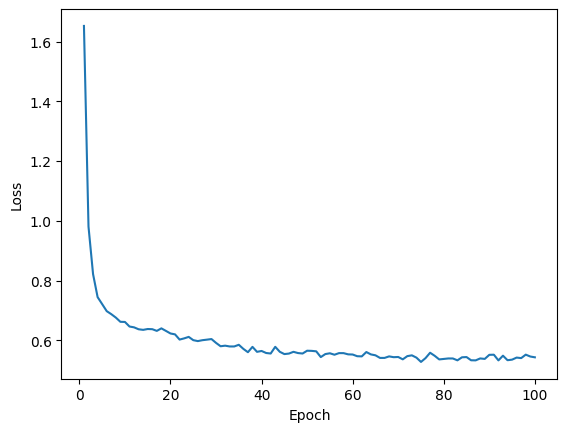

In [52]:
loss = np.loadtxt("loss_vs_epoch_tau1.txt", skiprows=1)
plt.plot(np.arange(1, len(loss)+1), loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")


## Sampling: generare x dato c
- Genero un valore di x (cioè il mio pt normalizzato) dato il contesto c, integrando nel tempo il campo di velocità 

In [60]:
def sample_x_given_c(c, steps=50):
    """
    c: [B, Dc] (normalized)
    returns: x1_hat [B, Dx] (normalized)
    """
    vf.eval()

    # disattivo grad sui parametri (ma NON su x) -> durante il sampling non voglio aggiornare i pesi ma voglio ancora grad(x)
    was_req = []
    for p in vf.parameters():
        was_req.append(p.requires_grad)
        p.requires_grad_(False)

    B = c.shape[0]
    x = torch.randn((B, Dx), device=c.device)

    # Loop di integrazione ODE: Eulero 
    with torch.enable_grad():  
        for k in range(steps):
            t = torch.full((B,), k / steps, device=c.device)

            
            x = x.detach().requires_grad_(True) 
            v = vf(x, t, c)      
            x = x + (1.0 / steps) * v



    # ripristino requires_grad dei parametri
    for p, req in zip(vf.parameters(), was_req):
        p.requires_grad_(req)

    return x.detach()



In [61]:
x1_batch, c_batch = next(iter(dl))
c_batch = c_batch.to(device)[:1024]

x_hat_n = sample_x_given_c(c_batch, steps=80).cpu().numpy()
x_hat = scaler_X.inverse_transform(x_hat_n) # passaggio inverso della normalizzazione -> ora x_hat è in unità fisiche 

# check :
print(x_hat.shape)


(1024, 1)


In [62]:
# 1) prendo un batch dal dataloader
x_true_n, c_batch = next(iter(dl))   # normalized
x_true_n = x_true_n.to(device)
c_batch  = c_batch.to(device)

# (opzionale) riduco per velocità
B = 4096
x_true_n = x_true_n[:B]
c_batch  = c_batch[:B]

# 2) genero x_hat (normalized) con il sampler
x_hat_n = sample_x_given_c(c_batch, steps=80)   # tensor [B,1] normalized

# 3) porto su CPU e denormalizzo (torno in GeV)
x_true = scaler_X.inverse_transform(x_true_n.detach().cpu().numpy()) # [B, 1]
x_hat  = scaler_X.inverse_transform(x_hat_n.detach().cpu().numpy())  # [B, 1]


# 4) residui su pT
res = x_hat - x_true

rmse = float(np.sqrt(np.mean(res**2)))
bias = float(np.mean(res))

print("RMSE (pT_gen in GeV):", rmse)
print("BIAS (pT_gen in GeV):", bias)



RMSE (pT_gen in GeV): 15.757667541503906
BIAS (pT_gen in GeV): 0.2730942964553833


In [63]:
# x_true e x_hat sono già pT in GeV, shape (B,1)
pt_true = x_true[:, 0]
pt_hat  = x_hat[:, 0]

r = pt_hat / pt_true

print("Tau1 pT response: mean =", r.mean(), " std =", r.std())

p16, p50, p84 = np.percentile(r, [16, 50, 84])
print("Tau1 response percentili 16/50/84:", p16, p50, p84)



Tau1 pT response: mean = 1.0209148  std = 0.22445476
Tau1 response percentili 16/50/84: 0.8508343458175659 1.0002427697181702 1.168989038467407


In [65]:
from torch.utils.data import Dataset, DataLoader

class IndexedDataset(Dataset):
    def __init__(self, X_t, C_t):
        self.X_t = X_t
        self.C_t = C_t
    def __len__(self):
        return len(self.X_t)
    def __getitem__(self, i):
        return self.X_t[i], self.C_t[i], i

dl_idx = DataLoader(IndexedDataset(X_t, C_t), batch_size=4096, shuffle=False, drop_last=True)


In [66]:
# batch con indici
x_true_n, c_batch, idx = next(iter(dl_idx))
x_true_n = x_true_n.to(device)
c_batch  = c_batch.to(device)
idx = idx.numpy()

# predizione (normalized -> GeV)
x_hat_n = sample_x_given_c(c_batch, steps=80).detach().cpu().numpy()
pt_pred = scaler_X.inverse_transform(x_hat_n).reshape(-1) # [B]

# gen true (normalized -> GeV)
pt_gen  = scaler_X.inverse_transform(
    x_true_n.detach().cpu().numpy()
).reshape(-1) # [B]
# reco pT dal dataframe: tau1_logpt è davvero log(pt)
sub = df_DY_event.iloc[idx]
pt_reco = np.exp(sub["tau1_logpt"].to_numpy(np.float32))  # [B]


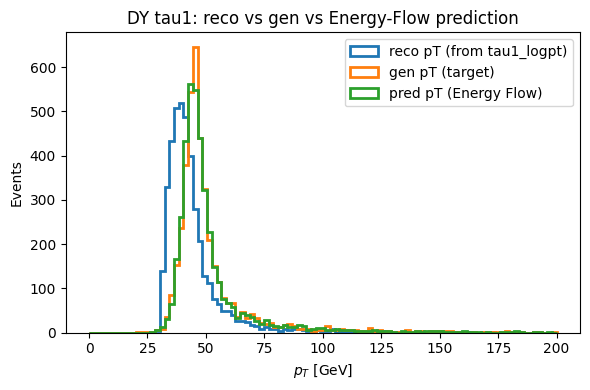

In [67]:
plt.figure(figsize=(6,4))
bins = np.linspace(0, 200, 100)

plt.hist(pt_reco, bins=bins, histtype="step", linewidth=2, label="reco pT (from tau1_logpt)")
plt.hist(pt_gen,  bins=bins, histtype="step", linewidth=2, label="gen pT (target)")
plt.hist(pt_pred, bins=bins, histtype="step", linewidth=2, label="pred pT (Energy Flow)")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("DY tau1: reco vs gen vs Energy-Flow prediction")
plt.legend()
plt.tight_layout()
plt.show()


# Test su Higgs (modello addestrato su DY) $\rightarrow$ (?)

In [68]:
# stesso c_cols usato nel training DY
C_H = df_H_event[c_cols_tau1].to_numpy(np.float32)

# normalizzo 
C_Hn = scaler_C.transform(C_H).astype(np.float32)

c_H = torch.from_numpy(C_Hn).to(device)


In [69]:
def sample_in_batches(c_all, steps=80, batch_size=512):
    outs = []
    for i in range(0, c_all.shape[0], batch_size):
        c_b = c_all[i:i+batch_size]
        x_b = sample_x_given_c(c_b, steps=steps).detach().cpu().numpy()
        outs.append(x_b)
    return np.concatenate(outs, axis=0)

# c_H: Tensor [N, Dc] già su device e normalizzato
x_hat_H_n = sample_in_batches(c_H, steps=80, batch_size=512)

pt_pred_H = scaler_X.inverse_transform(x_hat_H_n).reshape(-1)

In [70]:
# gen (truth Higgs)
pt_gen_H = df_H_event["gen_tau1_logpt"].to_numpy(np.float32)   # è già pT in GeV (non è log !!!)

# reco (Higgs)
pt_reco_H = np.exp(df_H_event["tau1_logpt"].to_numpy(np.float32))

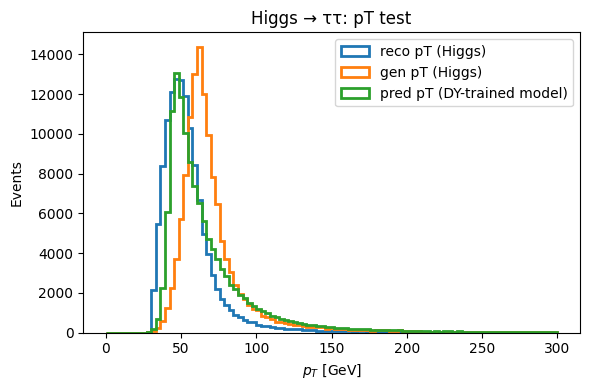

In [71]:
bins = np.linspace(0, 300, 100)

plt.figure(figsize=(6,4))
plt.hist(pt_reco_H, bins=bins, histtype="step", linewidth=2, label="reco pT (Higgs)")
plt.hist(pt_gen_H,  bins=bins, histtype="step", linewidth=2, label="gen pT (Higgs)")
plt.hist(pt_pred_H, bins=bins, histtype="step", linewidth=2, label="pred pT (DY-trained model)")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("Higgs → ττ: pT test")
plt.legend()
plt.tight_layout()
plt.show()

# Primo Test
Applico il modello trainato su tau1-DY a tau2-DY

In [198]:
# ---- costruisco le colonne contesto per tau2 mantenendo l'ordine del training ----
c_cols_tau2 = [col.replace("tau1_", "tau2_") for col in c_cols] 

# check rapido: colonne mancanti
missing = [col for col in c_cols_tau2 if col not in df_DY_tau2.columns]
print("Missing columns:", missing)

# ---- estraggo, normalizzo con lo scaler del training, porto su torch ----
C_DY2 = df_DY_tau2[c_cols_tau2].to_numpy(np.float32)
C_DY2_n = scaler_C.transform(C_DY2).astype(np.float32)

c_DY = torch.from_numpy(C_DY2_n).to(device)
print("c_DY shape:", c_DY.shape)


Missing columns: []
c_DY shape: torch.Size([60113, 31])


In [199]:
x_hat_DY_n = sample_in_batches(c_DY, steps=80, batch_size=512)
pt_pred_DY = scaler_X.inverse_transform(x_hat_DY_n).reshape(-1)

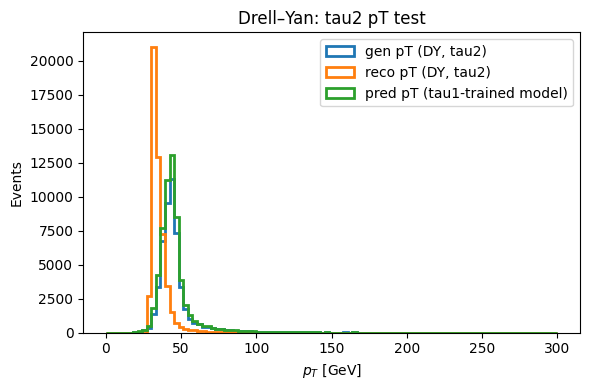

In [218]:
# gen (truth DY)  -- ATTENZIONE: non è log
pt_gen_DY = df_DY_tau2["gen_tau2_logpt"].to_numpy(np.float32)

# reco (DY)  -- qui è log 
pt_reco_DY = np.exp(df_DY_tau2["tau2_logpt"].to_numpy(np.float32))

bins = np.linspace(0, 300, 100)

plt.figure(figsize=(6,4))
plt.hist(pt_gen_DY,  bins=bins, histtype="step", linewidth=2, label="gen pT (DY, tau2)")
plt.hist(pt_reco_DY, bins=bins, histtype="step", linewidth=2, label="reco pT (DY, tau2)")
plt.hist(pt_pred_DY, bins=bins, histtype="step", linewidth=2, label="pred pT (tau1-trained model)")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("Drell–Yan: tau2 pT test")
plt.legend()
plt.tight_layout()
plt.show()


# Test 0 - Massa invariante 

(Training solo su Tau1)

In [72]:
# ===== DY: tau1 pred  =====
C1 = df_DY_event[c_cols].to_numpy(np.float32)                 # c_cols = contesto tau1 del training
C1n = scaler_C.transform(C1).astype(np.float32)
c1  = torch.from_numpy(C1n).to(device)

with torch.no_grad():
    xhat1_n = sample_in_batches(c1, steps=80, batch_size=512)

df_DY_event["tau1_pt_pred"] = scaler_X.inverse_transform(xhat1_n).reshape(-1).astype(np.float32)

# ===== DY: tau2 pred (stesso modello, contesto tau2) =====
c_cols_tau2 = [col.replace("tau1_", "tau2_") for col in c_cols]
C2 = df_DY_event[c_cols_tau2].to_numpy(np.float32)
C2n = scaler_C.transform(C2).astype(np.float32)
c2  = torch.from_numpy(C2n).to(device)

with torch.no_grad():
    xhat2_n = sample_in_batches(c2, steps=80, batch_size=512)

df_DY_event["tau2_pt_pred"] = scaler_X.inverse_transform(xhat2_n).reshape(-1).astype(np.float32)

print("Saved predictions into df_DY_event: tau1_pt_pred, tau2_pt_pred")


Saved predictions into df_DY_event: tau1_pt_pred, tau2_pt_pred


In [202]:
# ===== Higgs: tau1 pred =====
C1H = df_H_event[c_cols].to_numpy(np.float32)
C1Hn = scaler_C.transform(C1H).astype(np.float32)
c1H  = torch.from_numpy(C1Hn).to(device)

with torch.no_grad():
    xhat1H_n = sample_in_batches(c1H, steps=80, batch_size=512)

df_H_event["tau1_pt_pred"] = scaler_X.inverse_transform(xhat1H_n).reshape(-1).astype(np.float32)

# ===== Higgs: tau2 pred =====
C2H = df_H_event[c_cols_tau2].to_numpy(np.float32)  # riuso c_cols_tau2 definita sopra
C2Hn = scaler_C.transform(C2H).astype(np.float32)
c2H  = torch.from_numpy(C2Hn).to(device)

with torch.no_grad():
    xhat2H_n = sample_in_batches(c2H, steps=80, batch_size=512)

df_H_event["tau2_pt_pred"] = scaler_X.inverse_transform(xhat2H_n).reshape(-1).astype(np.float32)

print("Saved predictions into df_H_event: tau1_pt_pred, tau2_pt_pred")


Saved predictions into df_H_event: tau1_pt_pred, tau2_pt_pred


In [203]:
def fourvec_from_pt_eta_phi_m(pt, eta, phi, m):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E  = np.sqrt(px**2 + py**2 + pz**2 + m**2)
    return E, px, py, pz

def inv_mass(E1,px1,py1,pz1, E2,px2,py2,pz2):
    E  = E1 + E2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    m2 = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(np.maximum(m2, 0.0))

def add_mvis(df_in):
    df = df_in.copy()

    eta1 = df["tau1_eta"].to_numpy(np.float32)
    phi1 = df["tau1_phi"].to_numpy(np.float32)
    m1   = df["tau1_mass"].to_numpy(np.float32)

    eta2 = df["tau2_eta"].to_numpy(np.float32)
    phi2 = df["tau2_phi"].to_numpy(np.float32)
    m2   = df["tau2_mass"].to_numpy(np.float32)

    pt1_reco = np.exp(df["tau1_logpt"].to_numpy(np.float32))
    pt2_reco = np.exp(df["tau2_logpt"].to_numpy(np.float32))

    pt1_pred = df["tau1_pt_pred"].to_numpy(np.float32)
    pt2_pred = df["tau2_pt_pred"].to_numpy(np.float32)

    E1,px1,py1,pz1 = fourvec_from_pt_eta_phi_m(pt1_reco, eta1, phi1, m1)
    E2,px2,py2,pz2 = fourvec_from_pt_eta_phi_m(pt2_reco, eta2, phi2, m2)
    df["mvis_reco"] = inv_mass(E1,px1,py1,pz1, E2,px2,py2,pz2).astype(np.float32)

    E1p,px1p,py1p,pz1p = fourvec_from_pt_eta_phi_m(pt1_pred, eta1, phi1, m1)
    E2p,px2p,py2p,pz2p = fourvec_from_pt_eta_phi_m(pt2_pred, eta2, phi2, m2)
    df["mvis_pred"] = inv_mass(E1p,px1p,py1p,pz1p, E2p,px2p,py2p,pz2p).astype(np.float32)

    return df

df_DY_event = add_mvis(df_DY_event)
df_H_event  = add_mvis(df_H_event)

# print("Added: mvis_reco, mvis_pred to df_DY_event and df_H_event")

In [204]:
# check
print(df_DY_event[["mvis_reco","mvis_pred"]].describe())
print(df_H_event[["mvis_reco","mvis_pred"]].describe())

          mvis_reco     mvis_pred
count  51425.000000  51425.000000
mean      79.568344     96.869713
std       19.458309     29.502375
min       23.887779     24.787899
25%       71.110550     89.690025
50%       77.060654     91.172417
75%       83.743584     93.238716
max      771.485901   1168.936646
           mvis_reco      mvis_pred
count  128034.000000  128034.000000
mean       91.950279     124.209290
std        15.084457       3.121297
min        19.193403      31.010740
25%        81.568380     123.963932
50%        91.659187     124.685501
75%       102.095442     125.317831
max       184.319061     151.444870


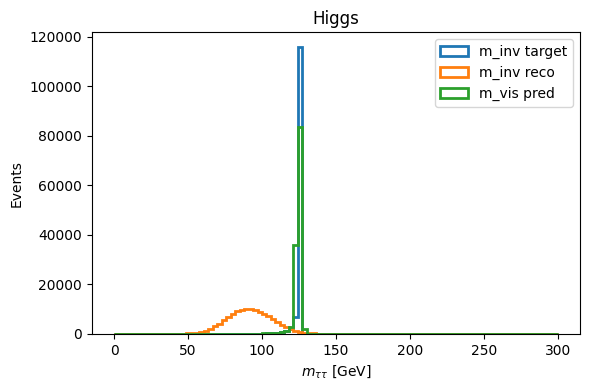

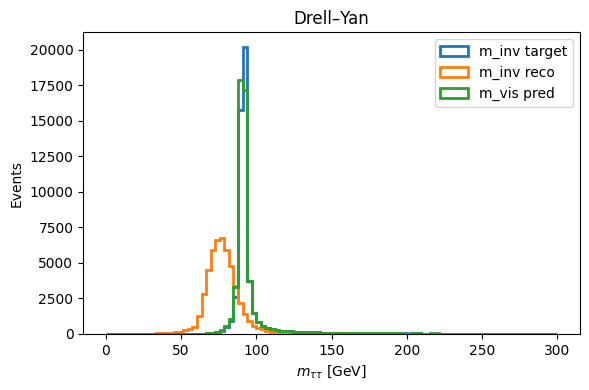

In [206]:
def plot_all_masses(df, label, bins=None):
    if bins is None:
        bins = np.linspace(0, 300, 100)

    # check colonne necessarie
    required = ["inv_mass_tar", "inv_mass_reco", "mvis_pred"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"{label}: mancano le colonne {missing}")

    plt.figure(figsize=(6,4))
    plt.hist(df["inv_mass_tar"].to_numpy(np.float32),
             bins=bins, histtype="step", linewidth=2, label="m_inv target")
    plt.hist(df["inv_mass_reco"].to_numpy(np.float32),
             bins=bins, histtype="step", linewidth=2, label="m_inv reco")
    plt.hist(df["mvis_pred"].to_numpy(np.float32),
             bins=bins, histtype="step", linewidth=2, label="m_vis pred")

    plt.xlabel(r"$m_{\tau\tau}$ [GeV]")
    plt.ylabel("Events")
    plt.title(label)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ======= Plot =======
plot_all_masses(df_H_event, "Higgs")
plot_all_masses(df_DY_event, "Drell–Yan")


# Test 1 - Training anche su Tau2

In [73]:
# ===== TAU 2 =====

# dataframe event-level DY post TauID
df_DY_tau2 = df_DY_event

# x = target (gen pT del tau2)  [come prima: logpt]
x_cols = ["gen_tau2_logpt"]   # Dx = 1

# c = contesto (feature reco del tau2)
c_cols = [c for c in df_DY_tau2.columns if c.startswith("tau2_")]
c_cols += ["inv_mass_reco"]

drop_cols = {
    "tau2_pt_gen",
    "tau2_ptreco_over_ptgen",
    "tau2_response",
    "tau2_resolution",
    "tau2_response_corrPNet",
    "tau2_resolution_corrPNet",
    "inv_mass_reco",
}

c_cols = [c for c in c_cols if c not in drop_cols]

print("Dc =", len(c_cols))
print("Removed:", [c for c in drop_cols if c in df_DY_tau2.columns])
print("Still present (should be empty):", [c for c in c_cols if c in drop_cols])


X = df_DY_tau2[x_cols].to_numpy(np.float32)   # (N,1)
C = df_DY_tau2[c_cols].to_numpy(np.float32)   # (N,Dc)

print("X shape:", X.shape)
print("C shape:", C.shape)

# ======= Scaling (sklearn) ========
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_C = StandardScaler()

Xn = scaler_X.fit_transform(X).astype(np.float32)
Cn = scaler_C.fit_transform(C).astype(np.float32)

from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
from torch import Tensor

device = "cuda" if torch.cuda.is_available() else "cpu"

X_t = torch.from_numpy(Xn)
C_t = torch.from_numpy(Cn)

ds = TensorDataset(X_t, C_t)
dl = DataLoader(ds, batch_size=4096, shuffle=True, drop_last=True)


# funzione di attivazione
class Swish(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        return torch.sigmoid(x) * x

class ConditionalEnergyMLP(nn.Module):
    def __init__(self, Dx: int, Dc: int, hidden_dim: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Dx + Dc + 1, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: Tensor, t: Tensor, c: Tensor) -> Tensor:
        if t.ndim == 1:
            t = t[:, None]
        h = torch.cat([x, c, t], dim=1)
        return self.net(h)

class EnergyToVelocity(nn.Module):
    def __init__(self, energy_net: nn.Module, sign: float = -1.0):
        super().__init__()
        self.energy_net = energy_net
        self.sign = sign

    def forward(self, x: Tensor, t: Tensor, c: Tensor) -> Tensor:
        x_req = x.requires_grad_(True)
        E = self.energy_net(x_req, t, c)
        grad_x = torch.autograd.grad(E.sum(), x_req, create_graph=True)[0]
        return self.sign * grad_x


Dx = Xn.shape[1]
Dc = Cn.shape[1]

energy_net = ConditionalEnergyMLP(Dx=Dx, Dc=Dc, hidden_dim=512).to(device)
vf = EnergyToVelocity(energy_net).to(device)

opt = torch.optim.Adam(energy_net.parameters(), lr=1e-3)

def linear_path_sample(x0, x1, t):
    t_ = t[:, None]
    x_t = (1 - t_) * x0 + t_ * x1
    dx_t = x1 - x0
    return x_t, dx_t


epochs = 100
loss_history = []

for ep in range(epochs):
    running = 0.0
    for x1, c in dl:
        x1 = x1.to(device)
        c  = c.to(device)

        B = x1.shape[0]
        x0 = torch.randn_like(x1)
        t = torch.rand((B,), device=device)

        x_t, dx_t = linear_path_sample(x0, x1, t)

        v_pred = vf(x_t, t, c)
        loss = (v_pred - dx_t).pow(2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        running += loss.item()

    epoch_loss = running / len(dl)
    loss_history.append(epoch_loss)

    print(f"epoch {ep+1}/{epochs}  loss={epoch_loss:.6f}")


Dc = 25
Removed: ['tau2_response', 'tau2_ptreco_over_ptgen', 'tau2_resolution', 'tau2_response_corrPNet', 'tau2_pt_gen', 'tau2_resolution_corrPNet', 'inv_mass_reco']
Still present (should be empty): []
X shape: (51425, 1)
C shape: (51425, 25)
epoch 1/100  loss=1.755232
epoch 2/100  loss=1.358531
epoch 3/100  loss=1.213845
epoch 4/100  loss=1.098091
epoch 5/100  loss=1.026326
epoch 6/100  loss=1.015100
epoch 7/100  loss=0.974889
epoch 8/100  loss=0.974765
epoch 9/100  loss=0.983071
epoch 10/100  loss=0.937693
epoch 11/100  loss=0.963664
epoch 12/100  loss=0.939469
epoch 13/100  loss=0.935045
epoch 14/100  loss=0.917589
epoch 15/100  loss=0.916411
epoch 16/100  loss=0.909905
epoch 17/100  loss=0.918896
epoch 18/100  loss=0.895782
epoch 19/100  loss=0.913380
epoch 20/100  loss=0.894200
epoch 21/100  loss=0.890429
epoch 22/100  loss=0.886859
epoch 23/100  loss=0.877631
epoch 24/100  loss=0.889114
epoch 25/100  loss=0.874840
epoch 26/100  loss=0.869144
epoch 27/100  loss=0.881273
epoch 28/1

In [ ]:
# --- salvo con nomi piu' indicativi ---
vf_tau2 = vf
scaler_X_tau2 = scaler_X
scaler_C_tau2 = scaler_C
c_cols_tau2 = c_cols
sample_x_given_c_tau2 = sample_x_given_c


In [ ]:
epochs_arr = np.arange(1, epochs+1)

plt.figure(figsize=(6,4))
plt.plot(epochs_arr, loss_history, marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Energy Flow training loss (tau2)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


Tau2 pT response: mean = 1.0305266  std = 0.2660802
Tau2 response percentili 16/50/84: 0.8283011794090271 0.9999789297580719 1.2062670230865478


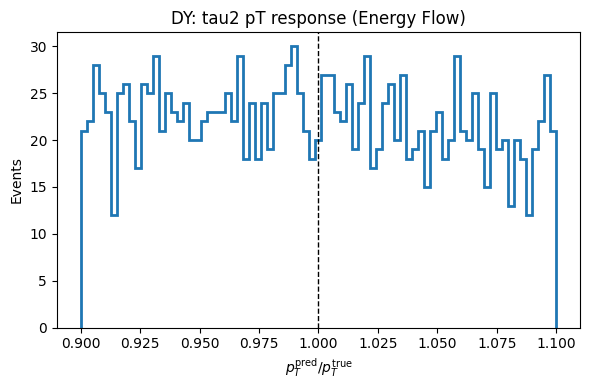

In [74]:
def sample_x_given_c(c, steps=50):
    vf.eval()

    was_req = []
    for p in vf.parameters():
        was_req.append(p.requires_grad)
        p.requires_grad_(False)

    B = c.shape[0]
    x = torch.randn((B, Dx), device=c.device)

    with torch.enable_grad():
        for k in range(steps):
            t = torch.full((B,), k / steps, device=c.device)
            v = vf(x, t, c)
            x = x + (1.0 / steps) * v
            x = x.detach()

    for p, req in zip(vf.parameters(), was_req):
        p.requires_grad_(req)

    return x


# --- batch ---
x_true_n, c_batch = next(iter(dl))
x_true_n = x_true_n.to(device)
c_batch  = c_batch.to(device)

B = 4096
x_true_n = x_true_n[:B]
c_batch  = c_batch[:B]

x_hat_n = sample_x_given_c(c_batch, steps=80)

x_true = scaler_X.inverse_transform(x_true_n.detach().cpu().numpy()) # logpt
x_hat  = scaler_X.inverse_transform(x_hat_n.detach().cpu().numpy())  # logpt

# pT in GeV:
pt_true = x_true[:, 0]
pt_hat  = x_hat[:, 0]

r = pt_hat / pt_true
print("Tau2 pT response: mean =", r.mean(), " std =", r.std())

p16, p50, p84 = np.percentile(r, [16, 50, 84])
print("Tau2 response percentili 16/50/84:", p16, p50, p84)

plt.figure(figsize=(6,4))
bins = np.linspace(0.9, 1.1, 80)
plt.hist(r, bins=bins, histtype="step", linewidth=2)
plt.axvline(1.0, color="k", linestyle="--", linewidth=1)
plt.xlabel(r"$p_T^{\mathrm{pred}} / p_T^{\mathrm{true}}$")
plt.ylabel("Events")
plt.title("DY: tau2 pT response (Energy Flow)")
plt.tight_layout()
plt.show()


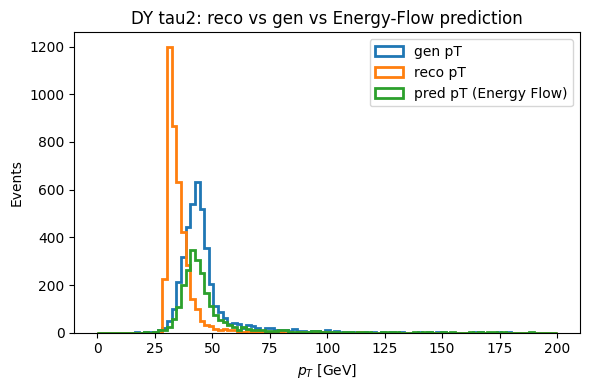

In [80]:
sub = df_DY_tau2.iloc[idx]

# reco: è ln(pT)
pt_reco = np.exp(sub["tau2_logpt"].to_numpy(np.float32))

# gen e pred: sono già pT in GeV
pt_gen  = scaler_X.inverse_transform(
    x_true_n.detach().cpu().numpy()
).reshape(-1)

pt_pred = scaler_X.inverse_transform(
    x_hat_n
).reshape(-1)

plt.figure(figsize=(6,4))
bins = np.linspace(0, 200, 100)

plt.hist(pt_gen,  bins=bins, histtype="step", linewidth=2, label="gen pT")
plt.hist(pt_reco, bins=bins, histtype="step", linewidth=2, label="reco pT")
plt.hist(pt_pred, bins=bins, histtype="step", linewidth=2, label="pred pT (Energy Flow)")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("DY tau2: reco vs gen vs Energy-Flow prediction")
plt.legend()
plt.tight_layout()
plt.show()


In [76]:
df_DY_event

,tau1_logpt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_response_corrPNet,tau2_response_corrPNet,tau1_dm,tau2_dm,tau1_resolution_corrPNet,tau2_resolution_corrPNet,tau1_pt_pred,tau2_pt_pred
2,3.674162,0.875122,-0.090088,0.646484,-0.000050,0.000212,1.153320,0.914062,0.984863,-1.0,...,45.458812,35.007927,0.974988,0.894771,1.0,10.0,-0.025012,-0.105229,54.153221,39.028019
6,3.694579,2.389160,1.977051,1.098633,-0.001568,0.005698,1.026367,0.996094,0.994629,1.0,...,41.289354,41.035457,0.902500,0.901878,10.0,1.0,-0.097500,-0.098122,45.941589,51.306133
9,3.875156,-0.371704,0.386658,1.157227,0.000169,-0.001055,1.019531,0.999023,0.997559,-1.0,...,49.131415,30.844352,0.929199,0.981132,10.0,1.0,-0.070801,-0.018868,48.343430,49.405193
17,3.964924,0.317871,1.018311,1.087891,-0.001331,-0.000872,0.998535,0.888672,0.994629,1.0,...,52.639059,31.170514,0.929608,0.623410,1.0,0.0,-0.070392,-0.376590,51.941898,30.976070
25,3.511394,1.427734,0.866943,1.159180,0.000447,0.009053,0.967773,0.906738,0.992188,1.0,...,32.415494,34.021892,0.743049,0.788913,1.0,10.0,-0.256951,-0.211087,53.777332,51.746540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335247,3.621049,0.668579,-1.771973,0.139526,0.001639,-0.000466,1.020508,0.988770,0.995605,-1.0,...,38.143286,37.213682,0.833733,0.860432,0.0,0.0,-0.166267,-0.139568,42.716427,41.211338
335248,3.866463,0.207764,-0.460815,8.117188,0.030228,0.039980,0.803223,0.996582,-1.000000,-1.0,...,38.372454,36.768819,0.730904,0.673113,1.0,0.0,-0.269096,-0.326887,41.383469,44.886574
335250,3.591280,0.836426,-0.882080,0.139526,-0.000064,0.000663,1.022461,0.869629,0.966797,-1.0,...,37.095369,31.822474,0.893864,0.740058,0.0,10.0,-0.106136,-0.259942,38.866131,36.184082
335252,3.735802,-0.003489,-0.321960,7.296875,-0.002762,0.010244,0.840332,0.984863,-1.000000,-1.0,...,35.228097,32.708994,0.924016,0.713003,1.0,10.0,-0.075984,-0.286997,38.178642,40.903244


In [81]:
# Non ho salvato tau2_pt_pred, quindi --> tau2_pt_pred_TrainingsuTau2

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) ricostruisco C dal dataframe con LE STESSE c_cols del training
C_full = df_DY_event[c_cols].to_numpy(np.float32)            # (N, Dc)
C_full_n = scaler_C.transform(C_full).astype(np.float32)     # normalize con scaler_C del training

# 2) sampling per tutti gli eventi in batch, mantenendo l'ordine del df
batch_size = 4096
N = C_full_n.shape[0]
pt_pred_tau2 = np.empty((N, 1), dtype=np.float32)

for start in range(0, N, batch_size):
    end = min(start + batch_size, N)

    c_batch = torch.from_numpy(C_full_n[start:end]).to(device)

    # output normalizzato (shape [B, Dx] = [B,1])
    x_hat_n = sample_x_given_c(c_batch, steps=80).detach().cpu().numpy()

    # denormalizzo -> unità fisiche (già pT in GeV)
    pt_pred_tau2[start:end] = scaler_X.inverse_transform(x_hat_n).astype(np.float32)

# 3) salvo la colonna nel dataframe
df_DY_event["tau2_pt_pred_TrainingsuTau2"] = pt_pred_tau2.reshape(-1)

print("Added column df_DY_event['tau2_pt_pred_TrainingsuTau2'] with shape:", df_DY_event["tau2_pt_pred_TrainingsuTau2"].shape)
print(df_DY_event["tau2_pt_pred_TrainingsuTau2"].describe())


Added column df_DY_event['tau2_pt_pred_TrainingsuTau2'] with shape: (51425,)
count    51425.000000
mean        46.381828
std         15.253420
min         14.223690
25%         39.530724
50%         43.138077
75%         47.853756
max        505.355988
Name: tau2_pt_pred_TrainingsuTau2, dtype: float64


In [82]:
def fourvec_from_pt_eta_phi_m(pt, eta, phi, m):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E  = np.sqrt(px**2 + py**2 + pz**2 + m**2)
    return E, px, py, pz

def inv_mass(E1,px1,py1,pz1, E2,px2,py2,pz2):
    E  = E1 + E2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    m2 = E**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(np.maximum(m2, 0.0))


df = df_DY_event

# pT predetti
pt1 = df["tau1_pt_pred"].to_numpy(np.float32)
pt2 = df["tau2_pt_pred_TrainingsuTau2"].to_numpy(np.float32)

# direzioni e masse reco
eta1 = df["tau1_eta"].to_numpy(np.float32)
phi1 = df["tau1_phi"].to_numpy(np.float32)
m1   = df["tau1_mass"].to_numpy(np.float32)

eta2 = df["tau2_eta"].to_numpy(np.float32)
phi2 = df["tau2_phi"].to_numpy(np.float32)
m2   = df["tau2_mass"].to_numpy(np.float32)

E1,px1,py1,pz1 = fourvec_from_pt_eta_phi_m(pt1, eta1, phi1, m1)
E2,px2,py2,pz2 = fourvec_from_pt_eta_phi_m(pt2, eta2, phi2, m2)

df["inv_mass_pred"] = inv_mass(E1,px1,py1,pz1, E2,px2,py2,pz2)


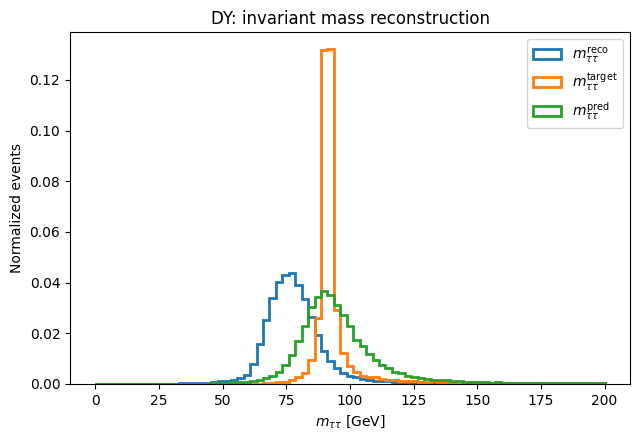

In [83]:
df = df_DY_event

m_reco = df["inv_mass_reco"].to_numpy(np.float32)
m_pred = df["inv_mass_pred"].to_numpy(np.float32)
m_true = df["inv_mass_tar"].to_numpy(np.float32)

# maschera di sicurezza
mask = (
    np.isfinite(m_reco) &
    np.isfinite(m_pred) &
    np.isfinite(m_true)
)

m_reco = m_reco[mask]
m_pred = m_pred[mask]
m_true = m_true[mask]

bins = np.linspace(0, 200, 80)

plt.figure(figsize=(6.5, 4.5))

plt.hist(
    m_reco,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label=r"$m_{\tau\tau}^{\mathrm{reco}}$"
)

plt.hist(
    m_true,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label=r"$m_{\tau\tau}^{\mathrm{target}}$"
)

plt.hist(
    m_pred,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label=r"$m_{\tau\tau}^{\mathrm{pred}}$"
)


plt.xlabel(r"$m_{\tau\tau}$ [GeV]")
plt.ylabel("Normalized events")
plt.title("DY: invariant mass reconstruction")
plt.legend()
plt.tight_layout()
plt.show()


## Applico all'Higgs

In [ ]:
# non so se la uso
def apply_pt_pred(df, c_cols, scaler_C, scaler_X, sample_x_given_c, steps=80, batch_size=4096):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # context -> normalized
    C = df[c_cols].to_numpy(np.float32)
    Cn = scaler_C.transform(C).astype(np.float32)

    N = Cn.shape[0]
    out = np.empty((N, 1), dtype=np.float32)

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        c_batch = torch.from_numpy(Cn[start:end]).to(device)

        x_hat_n = sample_x_given_c(c_batch, steps=steps).detach().cpu().numpy()   # (B,1) normalized
        out[start:end] = scaler_X.inverse_transform(x_hat_n).astype(np.float32)   # (B,1) physical

    return out.reshape(-1)


In [ ]:
# Predizione tau1 di Higgs:
C_H1 = df_H_event[c_cols_tau1].to_numpy(np.float32)
C_H1_n = scaler_C_tau1.transform(C_H1).astype(np.float32)

N = C_H1_n.shape[0]
pt_pred_tau1_H = np.empty((N, 1), dtype=np.float32)

for start in range(0, N, batch_size):
    end = min(start + batch_size, N)
    c_batch = torch.from_numpy(C_H1_n[start:end]).to(device)

    x_hat_n = sample_x_given_c_tau1(c_batch, steps=80).detach().cpu().numpy()
    pt_pred_tau1_H[start:end] = scaler_X_tau1.inverse_transform(x_hat_n)

df_H_event["tau1_pt_pred_TrainingsuTau1"] = pt_pred_tau1_H.reshape(-1)

In [ ]:
# Predizione tau2 di Higgs: 
C_H = df_H_event[c_cols].to_numpy(np.float32)       # c_cols = tau2_* + inv_mass_reco
C_H_n = scaler_C.transform(C_H).astype(np.float32)

batch_size = 4096
N = C_H_n.shape[0]
pt_pred_tau2_H = np.empty((N, 1), dtype=np.float32)

for start in range(0, N, batch_size):
    end = min(start + batch_size, N)
    c_batch = torch.from_numpy(C_H_n[start:end]).to(device)

    x_hat_n = sample_x_given_c(c_batch, steps=80).detach().cpu().numpy()
    pt_pred_tau2_H[start:end] = scaler_X.inverse_transform(x_hat_n)

df_H_event["tau2_pt_pred_TrainingsuTau2"] = pt_pred_tau2_H.reshape(-1)


In [ ]:
# check:
print(
    df_H_event[
        ["tau1_pt_pred_TrainingsuTau1",
         "tau2_pt_pred_TrainingsuTau2",
         "inv_mass_reco",
         "inv_mass_tar"]
    ].describe()
)

# Test 2 - Divido il Dataset in Training, Test e Validation